# Clasificación de Imágenes Otoscópicas

## Sub-ajuste, Ajuste Óptimo y Sobre-ajuste con MLP + CLIP

### Metodología CRISP-DM — implementación en **PyTorch puro**

**Dataset:** Otoscopic Image Dataset — 5 clases, 600 imágenes por clase  
**Pipeline:** Extracción de embeddings con CLIP ViT-B/32 (512 dims) → Clasificación con MLP  
**Objetivo pedagógico:** Demostrar empíricamente los 4 regímenes de entrenamiento usando `train_loss`, `val_loss` y `F1-score macro`

> **Stack:** PyTorch (`torch`, `open_clip`) + scikit-learn (métricas y splits)


In [ ]:
# ============================================================
# SETUP
# En Colab descomenta las dos líneas siguientes:
# !pip install open_clip_torch -q
# from google.colab import drive; drive.mount('/content/drive')
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import open_clip
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch    : {torch.__version__}")
print(f"Dispositivo: {DEVICE}")

/home/toopazo/Dropbox/tomas/repos_git/biy7121_mindatos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch    : 2.12.0+cpu
Dispositivo: cpu


In [ ]:
# ── Ejecución LOCAL ──────────────────────────────────────────
DATA_DIR = Path(
    "/home/toopazo/Dropbox/tomas/trabajo_duoc/AAA_datos/kaggle/Otoscopic_Data"
)
EMBED_DIR = Path("embeddings")

# ── Ejecución COLAB (descomentar) ────────────────────────────
# DATA_DIR  = Path('/content/drive/MyDrive/Otoscopic_Data')
# EMBED_DIR = Path('/content/drive/MyDrive/otoscopia_embeddings')

EMBED_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.exists(), f"No se encuentra: {DATA_DIR}"
print(f"Datos     : {DATA_DIR}")
print(f"Embeddings: {EMBED_DIR.resolve()}")

Datos     : /home/toopazo/Dropbox/tomas/trabajo_duoc/AAA_datos/kaggle/Otoscopic_Data
Embeddings: /home/toopazo/Dropbox/tomas/repos_git/biy7121_mindatos/ejemplo_sub_sobre_ajuste/embeddings


---

# FASE 1 — Entender el Negocio (CRISP-DM)

**Contexto clínico:** La otoscopía es el examen visual del canal auditivo externo y la membrana timpánica. Su interpretación requiere experiencia clínica y es propensa a variabilidad inter-observador. Un clasificador automático puede apoyar el diagnóstico en atención primaria.

| Clase                | Descripción                            |
| -------------------- | -------------------------------------- |
| Normal               | Membrana timpánica sana                |
| Acute Otitis Media   | Infección aguda del oído medio         |
| Chronic Otitis Media | Infección crónica, posible perforación |
| Cerumen Impaction    | Tapón de cera que obstruye el canal    |
| Myringosclerosis     | Calcificación de la membrana timpánica |

**Métrica de negocio:** F1-score macro — trata todas las clases por igual.  
**Pregunta:** ¿Cómo afectan las épocas y la capacidad del modelo al F1-score y la función de pérdida?


---

# FASE 2 — Entender los Datos (CRISP-DM)


Total imágenes: 3000
class
Acute Otitis Media      600
Cerumen Impaction       600
Chronic Otitis Media    600
Myringosclerosis        600
Normal                  600


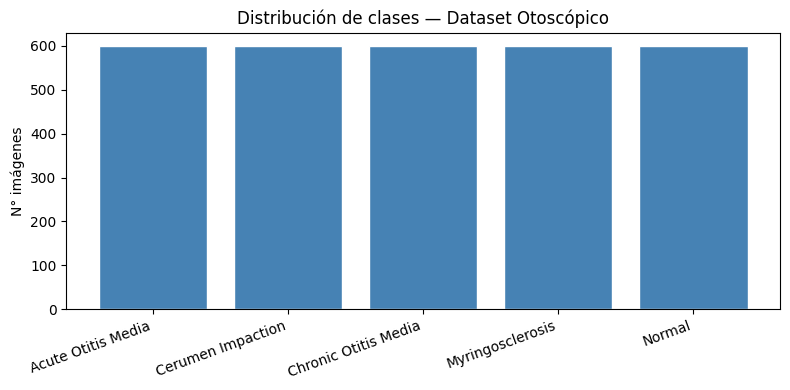

In [ ]:
CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

records = []
for class_name in CLASSES:
    for img_path in sorted((DATA_DIR / class_name).glob("*.jpg")):
        records.append(
            {
                "path": str(img_path),
                "label": CLASS2IDX[class_name],
                "class": class_name,
            }
        )

df = pd.DataFrame(records)
print(f"Total imágenes: {len(df)}")
print(df["class"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
counts = df["class"].value_counts()
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
ax.set_title("Distribución de clases — Dataset Otoscópico")
ax.set_ylabel("N° imágenes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

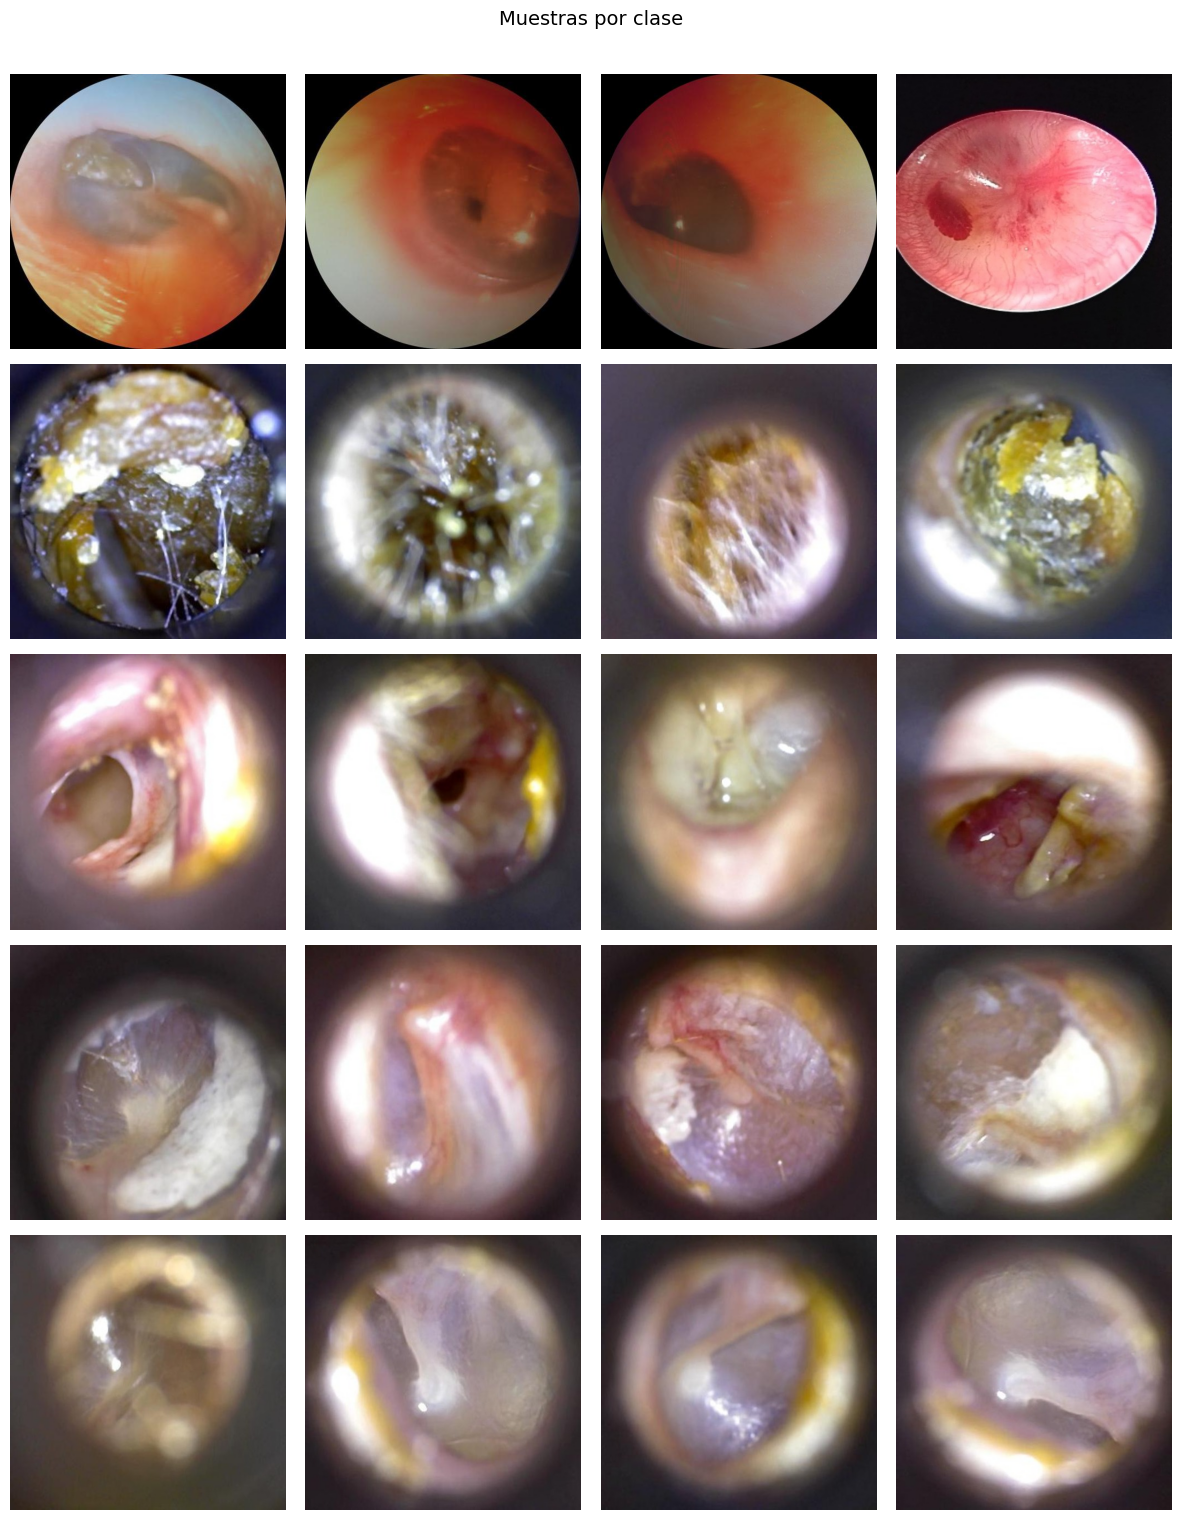

In [ ]:
N_SAMPLES = 4
fig, axes = plt.subplots(
    len(CLASSES), N_SAMPLES, figsize=(N_SAMPLES * 3, len(CLASSES) * 3)
)

for row, class_name in enumerate(CLASSES):
    subset = df[df["class"] == class_name].sample(N_SAMPLES, random_state=SEED)
    for col, (_, r) in enumerate(subset.iterrows()):
        axes[row, col].imshow(Image.open(r["path"]).convert("RGB"))
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                class_name, fontsize=9, rotation=0, labelpad=110, va="center"
            )

fig.suptitle("Muestras por clase", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

# FASE 3 — Preparar los Datos (CRISP-DM)

| Conjunto  | %   | Uso                                                |
| --------- | --- | -------------------------------------------------- |
| **Train** | 70% | Actualizar pesos (gradientes + backprop)           |
| **Val**   | 15% | Monitorear `val_loss` y `val_f1` por época         |
| **Test**  | 15% | Evaluación final honesta — se usa **una sola vez** |


In [ ]:
df_train, df_temp = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["label"], random_state=SEED
)

print(f"Train : {len(df_train):>5}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val   : {len(df_val):>5}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(df_test):>5}  ({len(df_test)/len(df)*100:.1f}%)")
print("\nBalance por clase (train / val / test):")
for c in CLASSES:
    print(
        f"  {c:<30}  "
        f'{(df_train["class"]==c).sum():>4} / '
        f'{(df_val["class"]==c).sum():>3} / '
        f'{(df_test["class"]==c).sum():>3}'
    )

Train :  2100  (70.0%)
Val   :   450  (15.0%)
Test  :   450  (15.0%)

Balance por clase (train / val / test):
  Acute Otitis Media               420 /  90 /  90
  Cerumen Impaction                420 /  90 /  90
  Chronic Otitis Media             420 /  90 /  90
  Myringosclerosis                 420 /  90 /  90
  Normal                           420 /  90 /  90


---

# FASE 4 — Modelar (CRISP-DM)

## Sub-etapa 4.1 — Extracción de Embeddings con CLIP

CLIP (_Contrastive Language-Image Pretraining_, Radford et al., ICML 2021) preentrenado en 400M pares imagen-texto. Su encoder visual `ViT-B/32` produce vectores de **512 dimensiones** sin fine-tuning. Los embeddings se guardan como `.npy` y se reutilizan.


In [ ]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(DEVICE)
clip_model.eval()
print(
    "CLIP ViT-B/32 cargado  |  embedding dim: 512  |  ~87M params (congelados)"
)

/home/toopazo/Dropbox/tomas/repos_git/biy7121_mindatos/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 cargado  |  embedding dim: 512  |  ~87M params (congelados)


In [ ]:
def extract_embeddings(df_split, model, preprocess, device, batch_size=64):
    all_emb, all_lbl = [], []
    paths = df_split["path"].tolist()
    labels = df_split["label"].tolist()
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size), desc="Extrayendo"):
            imgs = torch.stack(
                [
                    preprocess(Image.open(p).convert("RGB"))
                    for p in paths[i : i + batch_size]
                ]
            ).to(device)
            feats = model.encode_image(imgs)
            feats = feats / feats.norm(dim=-1, keepdim=True)  # L2-normalizar
            all_emb.append(feats.cpu().numpy())
            all_lbl.extend(labels[i : i + batch_size])
    return np.vstack(all_emb).astype(np.float32), np.array(all_lbl)


for split_name, split_df in [
    ("train", df_train),
    ("val", df_val),
    ("test", df_test),
]:
    ep = EMBED_DIR / f"embeddings_{split_name}.npy"
    lp = EMBED_DIR / f"labels_{split_name}.npy"
    if ep.exists() and lp.exists():
        print(f"[{split_name}] Ya existen, se omite.")
    else:
        emb, lbl = extract_embeddings(
            split_df, clip_model, clip_preprocess, DEVICE
        )
        np.save(ep, emb)
        np.save(lp, lbl)
        print(f"[{split_name}] Guardado  shape={emb.shape}")

Extrayendo: 100%|██████████| 33/33 [01:46<00:00,  3.24s/it]


[train] Guardado  shape=(2100, 512)


Extrayendo: 100%|██████████| 8/8 [00:20<00:00,  2.59s/it]


[val] Guardado  shape=(450, 512)


Extrayendo: 100%|██████████| 8/8 [00:18<00:00,  2.34s/it]

[test] Guardado  shape=(450, 512)


In [ ]:
X_train = np.load(EMBED_DIR / "embeddings_train.npy")
y_train = np.load(EMBED_DIR / "labels_train.npy")
X_val = np.load(EMBED_DIR / "embeddings_val.npy")
y_val = np.load(EMBED_DIR / "labels_val.npy")
X_test = np.load(EMBED_DIR / "embeddings_test.npy")
y_test = np.load(EMBED_DIR / "labels_test.npy")

print(f"X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}")
print(
    f"Norma L2 promedio (debe ser ≈ 1.0): {np.linalg.norm(X_train, axis=1).mean():.4f}"
)

X_train (2100, 512)  X_val (450, 512)  X_test (450, 512)
Norma L2 promedio (debe ser ≈ 1.0): 1.0000


---

## Sub-etapa 4.2 — Componentes PyTorch: MLP y loop de entrenamiento

### `build_mlp`

Usa `nn.Sequential` para apilar `Linear → ReLU → (Dropout)`. La capa de salida **no lleva Softmax** porque `nn.CrossEntropyLoss` aplica `log_softmax` internamente.

### `train_model` — loop explícito

En PyTorch el loop de entrenamiento es manual y explícito. Por cada época:

```
model.train()   ← activa Dropout
  Por cada batch:
    1. optimizer.zero_grad()          limpia gradientes
    2. loss = criterion(model(X), y)  forward + cross-entropy
    3. loss.backward()                backpropagation
    4. optimizer.step()               actualiza pesos

model.eval()    ← desactiva Dropout
with torch.no_grad():
    val_loss, train_f1, val_f1    solo forward, sin actualizar pesos
```


In [ ]:
# ── Constructor de MLP ────────────────────────────────────────
def build_mlp(hidden_units, dropout_rate=0.0, input_dim=512, n_classes=5):
    """
    Construye un MLP con nn.Sequential.
    Sin Softmax final: CrossEntropyLoss lo aplica internamente.
    """
    layers = []
    prev = input_dim
    for units in hidden_units:
        layers.append(nn.Linear(prev, units))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        prev = units
    layers.append(nn.Linear(prev, n_classes))
    return nn.Sequential(*layers)


def model_info(model, name=""):
    total = sum(p.numel() for p in model.parameters())
    print(f"── {name} ──")
    print(model)
    print(f"Parámetros entrenables: {total:,}\n")


# ── Loop de entrenamiento ─────────────────────────────────────
def train_model(
    model,
    X_tr,
    y_tr,
    X_v,
    y_v,
    epochs=100,
    batch_size=32,
    lr=1e-3,
    patience=None,
    device="cpu",
    verbose=True,
):
    """
    Loop de entrenamiento PyTorch.
    patience : int | None  -> activa EarlyStopping si se especifica
    Retorna  : (model, history)  donde history tiene listas por época
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(
        torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device)
    )
    loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    # Tensores fijos para evaluación (no se mueven por época)
    X_tr_t = torch.FloatTensor(X_tr).to(device)
    X_v_t = torch.FloatTensor(X_v).to(device)
    y_v_t = torch.LongTensor(y_v).to(device)

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_loss, patience_counter, best_state = float("inf"), 0, None

    for epoch in range(1, epochs + 1):

        # ── Fase 1: entrenamiento batch a batch ───────────────
        model.train()  # activa Dropout
        batch_losses = []
        for X_b, y_b in loader:
            optimizer.zero_grad()  # 1. limpiar gradientes
            loss = criterion(model(X_b), y_b)  # 2-3. forward + loss
            loss.backward()  # 4. backprop
            optimizer.step()  # 5. actualizar pesos
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # ── Fase 2: evaluación — sin gradientes ───────────────
        model.eval()  # desactiva Dropout
        with torch.no_grad():
            val_loss = criterion(model(X_v_t), y_v_t).item()
            tr_preds = model(X_tr_t).argmax(dim=1).cpu().numpy()
            v_preds = model(X_v_t).argmax(dim=1).cpu().numpy()

        tr_f1 = f1_score(y_tr, tr_preds, average="macro", zero_division=0)
        v_f1 = f1_score(y_v, v_preds, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(v_f1)

        if verbose and epoch % max(1, epochs // 10) == 0:
            print(
                f"  Época {epoch:>4}/{epochs}  "
                f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                f"val_f1={v_f1:.4f}"
            )

        # ── EarlyStopping ─────────────────────────────────────
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {
                    k: v.clone() for k, v in model.state_dict().items()
                }
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose:
                        print(
                            f"\n  EarlyStopping en época {epoch}  "
                            f"(mejor val_loss={best_val_loss:.4f})"
                        )
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)  # restaurar mejores pesos

    return model, history


# ── Evaluación sobre cualquier conjunto ──────────────────────
def evaluate_model(model, X, y, device="cpu"):
    """Retorna (loss, f1_macro, f1_weighted, predicciones)."""
    model.eval()
    X_t = torch.FloatTensor(X).to(device)
    y_t = torch.LongTensor(y).to(device)
    with torch.no_grad():
        logits = model(X_t)
        loss = nn.CrossEntropyLoss()(logits, y_t).item()
        preds = logits.argmax(dim=1).cpu().numpy()
    f1_mac = f1_score(y, preds, average="macro", zero_division=0)
    f1_w = f1_score(y, preds, average="weighted", zero_division=0)
    return loss, f1_mac, f1_w, preds


print(
    "Helpers definidos: build_mlp · model_info · train_model · evaluate_model"
)

Helpers definidos: build_mlp · model_info · train_model · evaluate_model


---

## Sub-etapa 4.3 — Sub-ajuste por TIEMPO

Arquitectura suficiente (`512→256→128→5`), entrenamiento cortado a **3 épocas**.  
**Señal esperada:** ambas losses altas y **todavía bajando** — el modelo podría mejorar con más épocas.


In [ ]:
torch.manual_seed(SEED)
mlp_subtiempo = build_mlp(hidden_units=[256, 128], dropout_rate=0.0)
model_info(mlp_subtiempo, "Sub-ajuste TIEMPO  (512→256→128→5, epochs=3)")

mlp_subtiempo, hist_subtiempo = train_model(
    mlp_subtiempo,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=3,
    batch_size=32,
    patience=None,
    device=DEVICE,
)

── Sub-ajuste TIEMPO  (512→256→128→5, epochs=3) ──
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=5, bias=True)
)
Parámetros entrenables: 164,869

  Época    1/3  train_loss=1.2069  val_loss=0.7003  val_f1=0.6316
  Época    2/3  train_loss=0.5426  val_loss=0.4193  val_f1=0.8588
  Época    3/3  train_loss=0.3476  val_loss=0.2736  val_f1=0.8962


---

## Sub-etapa 4.4 — Sub-ajuste por CAPACIDAD

Arquitectura diminuta (`512→4→5`), 200 épocas. El cuello de botella `512→4` es fundamentalmente insuficiente para 5 clases.  
**Señal esperada:** ambas losses altas y **planas** — más épocas no ayudan.


In [ ]:
torch.manual_seed(SEED)
mlp_subcap = build_mlp(hidden_units=[4], dropout_rate=0.0)
model_info(mlp_subcap, "Sub-ajuste CAPACIDAD  (512→4→5, epochs=200)")

mlp_subcap, hist_subcap = train_model(
    mlp_subcap,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
    patience=None,
    device=DEVICE,
)

── Sub-ajuste CAPACIDAD  (512→4→5, epochs=200) ──
Sequential(
  (0): Linear(in_features=512, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
)
Parámetros entrenables: 2,077

  Época   20/200  train_loss=0.5311  val_loss=0.5120  val_f1=0.8258
  Época   40/200  train_loss=0.3288  val_loss=0.3215  val_f1=0.9012
  Época   60/200  train_loss=0.2279  val_loss=0.2240  val_f1=0.9329
  Época   80/200  train_loss=0.1676  val_loss=0.1643  val_f1=0.9419
  Época  100/200  train_loss=0.1258  val_loss=0.1260  val_f1=0.9600
  Época  120/200  train_loss=0.0953  val_loss=0.1000  val_f1=0.9622
  Época  140/200  train_loss=0.0730  val_loss=0.0801  val_f1=0.9711
  Época  160/200  train_loss=0.0549  val_loss=0.0668  val_f1=0.9733
  Época  180/200  train_loss=0.0425  val_loss=0.0557  val_f1=0.9800
  Época  200/200  train_loss=0.0328  val_loss=0.0484  val_f1=0.9845


---

## Sub-etapa 4.5 — Ajuste Óptimo

Arquitectura moderada (`512→256→128→5`), `Dropout(0.3)` y **EarlyStopping** (`patience=15`).  
**Señal esperada:** ambas losses bajas y próximas, gap F1 pequeño y estable.


In [ ]:
torch.manual_seed(SEED)
mlp_optimo = build_mlp(hidden_units=[256, 128], dropout_rate=0.3)
model_info(mlp_optimo, "ÓPTIMO  (512→256→128→5, Dropout=0.3, EarlyStopping)")

mlp_optimo, hist_optimo = train_model(
    mlp_optimo,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
    patience=15,
    device=DEVICE,
)
print(f'Épocas efectivas: {len(hist_optimo["val_loss"])}')

── ÓPTIMO  (512→256→128→5, Dropout=0.3, EarlyStopping) ──
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=5, bias=True)
)
Parámetros entrenables: 164,869

  Época   20/200  train_loss=0.0386  val_loss=0.0361  val_f1=0.9888
  Época   40/200  train_loss=0.0103  val_loss=0.0374  val_f1=0.9911

  EarlyStopping en época 51  (mejor val_loss=0.0244)
Épocas efectivas: 51


---

## Sub-etapa 4.6 — Sobre-ajuste

Arquitectura grande (`512→1024→1024→512→5`), 200 épocas, **sin regularización**. ~2M parámetros para ~2.100 muestras.  
**Señal esperada:** `train_loss → ~0`, `val_loss` baja y luego **sube**, gap train/val crece.


In [ ]:
torch.manual_seed(SEED)
mlp_sobreaj = build_mlp(hidden_units=[1024, 1024, 512], dropout_rate=0.0)
model_info(mlp_sobreaj, "SOBRE-AJUSTE  (512→1024→1024→512→5, epochs=200)")

mlp_sobreaj, hist_sobreaj = train_model(
    mlp_sobreaj,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
    patience=None,
    device=DEVICE,
)
gap = hist_sobreaj["train_f1"][-1] - hist_sobreaj["val_f1"][-1]
print(
    f"Gap F1 final (train - val): {gap:.4f}  (cerca de 0=bien, grande=sobre-ajuste)"
)

── SOBRE-AJUSTE  (512→1024→1024→512→5, epochs=200) ──
Sequential(
  (0): Linear(in_features=512, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=1024, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1024, out_features=512, bias=True)
  (5): ReLU()
  (6): Linear(in_features=512, out_features=5, bias=True)
)
Parámetros entrenables: 2,102,277

  Época   20/200  train_loss=0.0009  val_loss=0.0200  val_f1=0.9889
  Época   40/200  train_loss=0.0000  val_loss=0.0271  val_f1=0.9911
  Época   60/200  train_loss=0.0000  val_loss=0.0409  val_f1=0.9911
  Época   80/200  train_loss=0.0000  val_loss=0.0454  val_f1=0.9888
  Época  100/200  train_loss=0.0000  val_loss=0.0487  val_f1=0.9888
  Época  120/200  train_loss=0.0000  val_loss=0.0513  val_f1=0.9888
  Época  140/200  train_loss=0.0000  val_loss=0.0539  val_f1=0.9888
  Época  160/200  train_loss=0.0000  val_loss=0.0560  val_f1=0.9888
  Época  180/200  train_loss=0.0000  val_loss=0.0584  val_f1=0.9888
 

---

# FASE 5 — Evaluar (CRISP-DM)

## 5.1 — Curvas de Pérdida: diagnóstico canónico

La divergencia entre `train_loss` y `val_loss` es el indicador estándar de sobre-ajuste (Goodfellow et al., 2016, Cap. 5). Estas curvas se calculan sobre **train y val** — el test nunca aparece aquí.


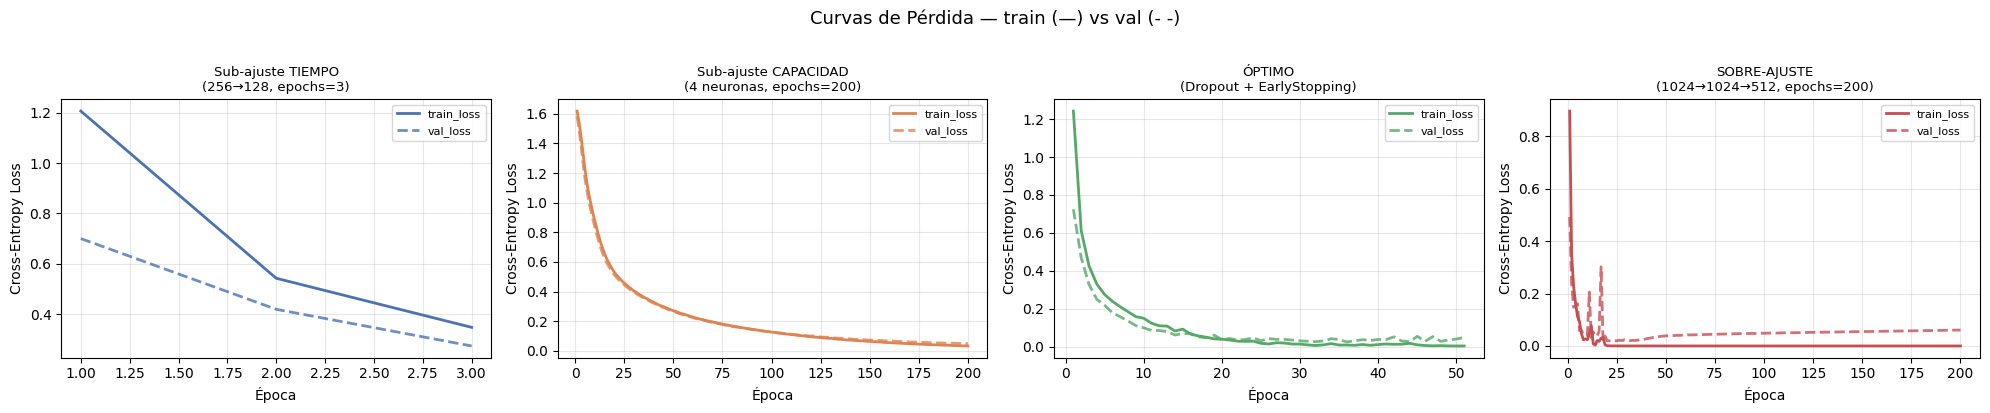

In [ ]:
experiments = [
    {
        "label": "Sub-ajuste TIEMPO\n(256→128, epochs=3)",
        "color": "#4C72B0",
        "hist": hist_subtiempo,
    },
    {
        "label": "Sub-ajuste CAPACIDAD\n(4 neuronas, epochs=200)",
        "color": "#DD8452",
        "hist": hist_subcap,
    },
    {
        "label": "ÓPTIMO\n(Dropout + EarlyStopping)",
        "color": "#55A868",
        "hist": hist_optimo,
    },
    {
        "label": "SOBRE-AJUSTE\n(1024→1024→512, epochs=200)",
        "color": "#C44E52",
        "hist": hist_sobreaj,
    },
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, exp in zip(axes, experiments):
    h = exp["hist"]
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(
        ep,
        h["train_loss"],
        lw=2,
        color=exp["color"],
        ls="-",
        label="train_loss",
    )
    ax.plot(
        ep,
        h["val_loss"],
        lw=2,
        color=exp["color"],
        ls="--",
        label="val_loss",
        alpha=0.8,
    )
    ax.set_title(exp["label"], fontsize=9.5)
    ax.set_xlabel("Época")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Curvas de Pérdida — train (—) vs val (- -)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5.2 — Curvas de F1-score: métrica de negocio

El mismo diagnóstico desde la perspectiva clínica. F1 es menos sensible que la loss pero directamente interpretable.


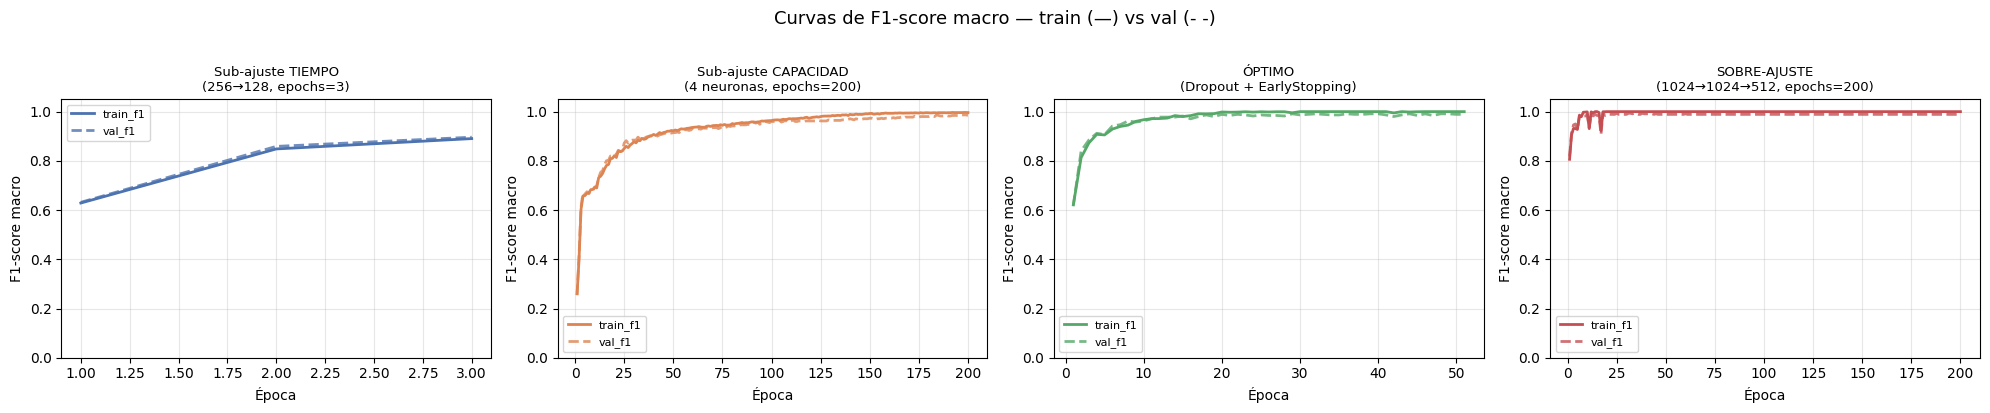

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, exp in zip(axes, experiments):
    h = exp["hist"]
    ep = range(1, len(h["train_f1"]) + 1)
    ax.plot(
        ep, h["train_f1"], lw=2, color=exp["color"], ls="-", label="train_f1"
    )
    ax.plot(
        ep,
        h["val_f1"],
        lw=2,
        color=exp["color"],
        ls="--",
        label="val_f1",
        alpha=0.8,
    )
    ax.set_title(exp["label"], fontsize=9.5)
    ax.set_xlabel("Época")
    ax.set_ylabel("F1-score macro")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Curvas de F1-score macro — train (—) vs val (- -)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

---

## 5.3 — Comparación: val_loss y val_f1 de los 4 modelos


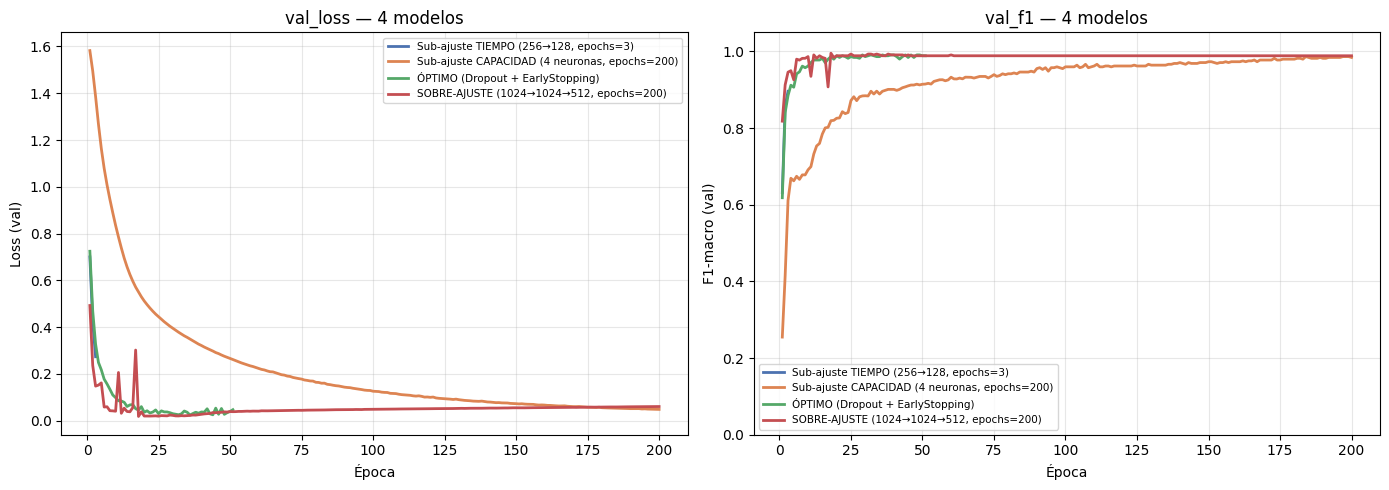

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for exp in experiments:
    h = exp["hist"]
    lbl = exp["label"].replace("\n", " ")
    ep = range(1, len(h["val_loss"]) + 1)
    ax1.plot(ep, h["val_loss"], lw=2, color=exp["color"], label=lbl)
    ax2.plot(ep, h["val_f1"], lw=2, color=exp["color"], label=lbl)

ax1.set_title("val_loss — 4 modelos")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss (val)")
ax1.legend(fontsize=7.5)
ax1.grid(alpha=0.3)

ax2.set_title("val_f1 — 4 modelos")
ax2.set_xlabel("Época")
ax2.set_ylabel("F1-macro (val)")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5.4 — Evaluación Final sobre el conjunto TEST

> Primer y único uso del test set. Estimación honesta y no sesgada.


In [ ]:
models_eval = {
    "Sub-ajuste Tiempo": mlp_subtiempo,
    "Sub-ajuste Capacidad": mlp_subcap,
    "Óptimo": mlp_optimo,
    "Sobre-ajuste": mlp_sobreaj,
}

rows = []
for nombre, model in models_eval.items():
    loss, f1_mac, f1_w, _ = evaluate_model(model, X_test, y_test, DEVICE)
    rows.append(
        {
            "Modelo": nombre,
            "test_loss": round(loss, 4),
            "F1-macro": round(f1_mac, 4),
            "F1-weighted": round(f1_w, 4),
        }
    )

df_results = pd.DataFrame(rows).set_index("Modelo")
print("=== Resultados sobre TEST ===")
print(df_results.to_string())
print(f'\nMejor modelo: {df_results["F1-macro"].idxmax()}')

=== Resultados sobre TEST ===
                      test_loss  F1-macro  F1-weighted
Modelo                                                
Sub-ajuste Tiempo        0.2894    0.8951       0.8951
Sub-ajuste Capacidad     0.0550    0.9867       0.9867
Óptimo                   0.0267    0.9867       0.9867
Sobre-ajuste             0.0630    0.9867       0.9867

Mejor modelo: Sub-ajuste Capacidad


---

## 5.5 — Matrices de Confusión sobre TEST


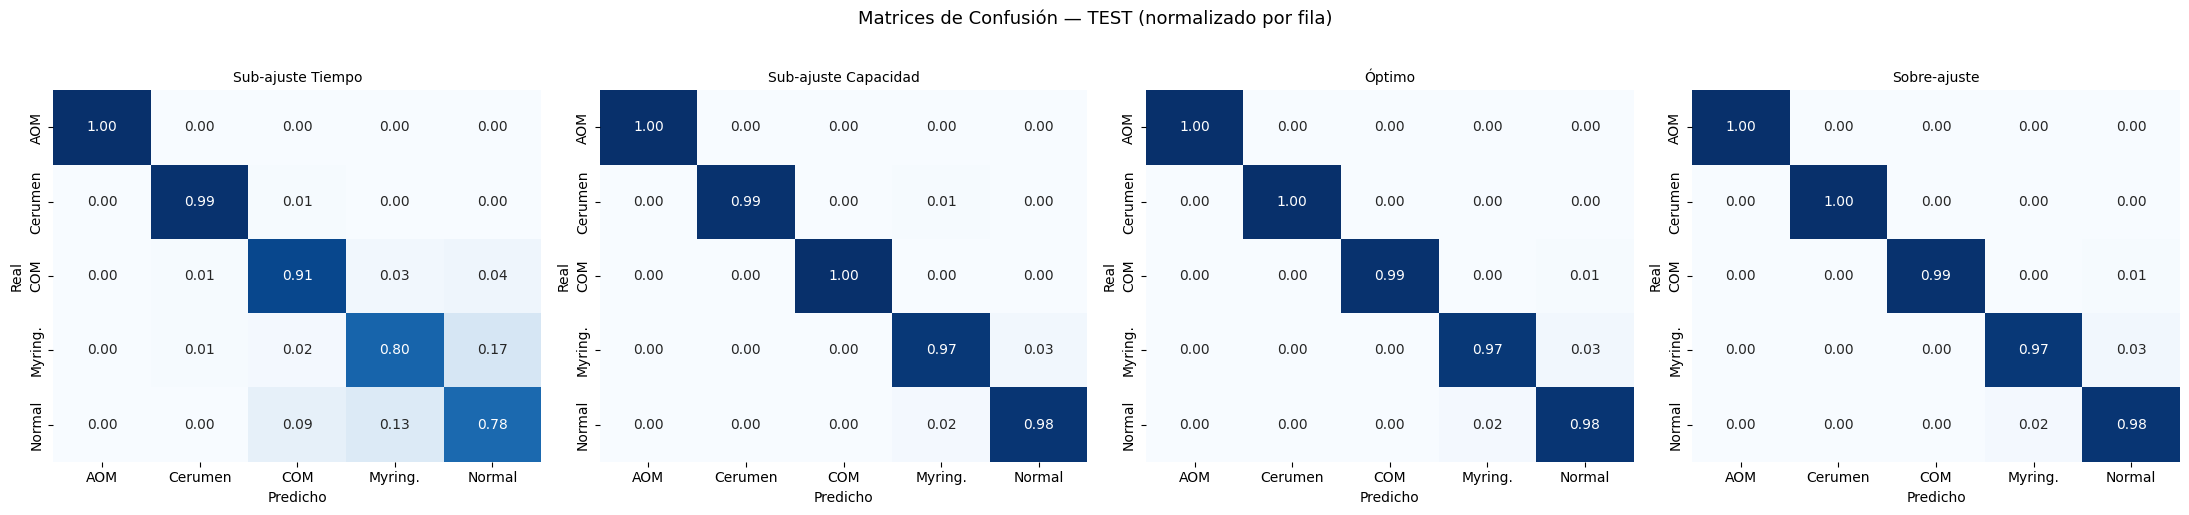

In [ ]:
SHORT = ["AOM", "Cerumen", "COM", "Myring.", "Normal"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (nombre, model) in zip(axes, models_eval.items()):
    _, _, _, preds = evaluate_model(model, X_test, y_test, DEVICE)
    cm = confusion_matrix(y_test, preds).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=SHORT,
        yticklabels=SHORT,
        ax=ax,
        vmin=0,
        vmax=1,
        cbar=False,
    )
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

fig.suptitle(
    "Matrices de Confusión — TEST (normalizado por fila)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

---

# Conclusiones

| Régimen                  | `train_loss`    | `val_loss`            | `val_f1`         | Causa                  |
| ------------------------ | --------------- | --------------------- | ---------------- | ---------------------- |
| **Sub-ajuste TIEMPO**    | Alta, bajando   | Alta, bajando         | Bajo             | Sin suficientes épocas |
| **Sub-ajuste CAPACIDAD** | Alta, **plana** | Alta, **plana**       | Bajo, estancado  | Límite estructural     |
| **Óptimo**               | Baja            | Baja, próxima a train | Alto             | Balance correcto       |
| **Sobre-ajuste**         | Muy baja (→ 0)  | Baja y luego **sube** | train≈1, val cae | Memorización           |

**Diferencia entre los dos sub-ajustes:**  
Por tiempo → losses bajando (podría mejorar). Por capacidad → losses planas (límite estructural).

**Por qué `val_loss` detecta sobreajuste antes que `val_f1`:**  
La cross-entropy penaliza la confianza incorrecta antes de que el argmax cambie. La loss es continua y más sensible que F1.

**Referencias:**

- Goodfellow, Bengio & Courville (2016). _Deep Learning_. MIT Press. Caps. 5 y 7.
- Radford et al. (2021). _Learning Transferable Visual Models From Natural Language Supervision_. ICML.
- Bishop (2006). _Pattern Recognition and Machine Learning_. Springer. Sec. 4.3.
